# IMU Data Analysis
Reads a rosbag and plots gyro, accelerometer, magnetometer, and orientation (Euler angles) time series.

In [53]:
from pathlib import Path
from rosbags.typesys import get_typestore, Stores, get_types_from_msg
from rosbags.rosbag2 import Reader
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [54]:
# --- Configuration ---
NOTEBOOK_DIR = Path("__file__").resolve().parent if "__file__" in dir() else Path().resolve()                                            
BAG_PATH = NOTEBOOK_DIR.parents[1] / "src/data/run2"
IMU_TOPIC = "/imu"
MSG_PATH = "/home/adrian/EECE5554/LAB3/src/imu_msg/msg/IMUmsg.msg"
MSG_TYPE = "imu_msg/msg/IMUmsg"

In [55]:
typestore = get_typestore(Stores.ROS2_HUMBLE)

def register_msg_file(typestore, msg_path: str, full_type_name: str):
    msg_text = Path(msg_path).read_text()
    add_types = get_types_from_msg(msg_text, full_type_name)
    typestore.register(add_types)

register_msg_file(typestore, MSG_PATH, MSG_TYPE)

In [56]:
def quaternion_to_euler(w, x, y, z):
    """Convert quaternion to Euler angles (roll, pitch, yaw) in degrees."""
    # Roll (x-axis)
    sinr_cosp = 2 * (w * x + y * z)
    cosr_cosp = 1 - 2 * (x * x + y * y)
    roll = np.arctan2(sinr_cosp, cosr_cosp)

    # Pitch (y-axis)
    sinp = 2 * (w * y - z * x)
    sinp = np.clip(sinp, -1.0, 1.0)
    pitch = np.arcsin(sinp)

    # Yaw (z-axis)
    siny_cosp = 2 * (w * z + x * y)
    cosy_cosp = 1 - 2 * (y * y + z * z)
    yaw = np.arctan2(siny_cosp, cosy_cosp)

    return np.degrees(roll), np.degrees(pitch), np.degrees(yaw)


def bag_to_df_imu(bag_path: str, typestore, topic: str = "/imu") -> pd.DataFrame:
    rows = []

    with Reader(bag_path) as reader:
        for connection, timestamp, rawdata in reader.messages():
            if connection.topic != topic:
                continue

            msg = typestore.deserialize_cdr(rawdata, connection.msgtype)

            qx = float(msg.imu.orientation.x)
            qy = float(msg.imu.orientation.y)
            qz = float(msg.imu.orientation.z)
            qw = float(msg.imu.orientation.w)
            roll, pitch, yaw = quaternion_to_euler(qw, qx, qy, qz)

            rows.append({
                "bag_time_ns": int(timestamp),

                # Gyroscope (rad/s)
                "gyro_x": float(msg.imu.angular_velocity.x),
                "gyro_y": float(msg.imu.angular_velocity.y),
                "gyro_z": float(msg.imu.angular_velocity.z),

                # Accelerometer (m/s^2)
                "accel_x": float(msg.imu.linear_acceleration.x),
                "accel_y": float(msg.imu.linear_acceleration.y),
                "accel_z": float(msg.imu.linear_acceleration.z),

                # Magnetometer (Tesla)
                "mag_x": float(msg.mag_field.magnetic_field.x),
                "mag_y": float(msg.mag_field.magnetic_field.y),
                "mag_z": float(msg.mag_field.magnetic_field.z),

                # Orientation quaternion
                "orient_qx": qx,
                "orient_qy": qy,
                "orient_qz": qz,
                "orient_qw": qw,

                # Euler angles (degrees)
                "roll_deg":  roll,
                "pitch_deg": pitch,
                "yaw_deg":   yaw,
            })

    df = pd.DataFrame(rows)
    df["time_s"] = (df["bag_time_ns"] - df["bag_time_ns"].iloc[0]) * 1e-9
    return df

In [57]:
df = bag_to_df_imu(BAG_PATH, typestore, topic=IMU_TOPIC)
print(f"Loaded {len(df)} IMU messages")
print(f"Duration: {df['time_s'].iloc[-1]:.2f} s")
df.head()

Loaded 311 IMU messages
Duration: 310.00 s


,bag_time_ns,gyro_x,gyro_y,gyro_z,accel_x,accel_y,accel_z,mag_x,mag_y,mag_z,orient_qx,orient_qy,orient_qz,orient_qw,roll_deg,pitch_deg,yaw_deg,time_s
0,1773420111148438063,0.048846,-0.017369,0.045116,-0.702,-0.006,-9.240,-0.000017,-0.000009,0.000043,0.702347,0.624568,0.334937,-0.066640,157.044,-33.623,90.312,0.000000
1,1773420112147570638,-0.085881,-0.052455,0.152695,-0.533,-0.524,-9.439,-0.000017,-0.000009,0.000043,0.737634,0.582887,0.330206,-0.084283,161.250,-35.831,82.743,0.999133
2,1773420113148476377,0.006567,-0.055151,0.113250,-0.883,-0.054,-9.443,-0.000016,-0.000009,0.000043,0.768744,0.546376,0.318779,-0.094262,165.365,-36.379,75.638,2.000038
3,1773420114146934971,0.040244,-0.031403,0.132364,-0.928,0.180,-9.831,-0.000016,-0.000009,0.000043,0.797755,0.502734,0.316712,-0.102662,168.762,-37.484,68.261,2.998497
4,1773420115147790258,0.014868,-0.038407,0.074267,-0.975,-0.334,-9.984,-0.000016,-0.000009,0.000044,0.828069,0.453739,0.305902,-0.121844,174.471,-38.111,59.352,3.999352


## a. Gyroscope (X, Y, Z)

In [58]:

def plot_gyro(df: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(df["time_s"], df["gyro_x"], label="X", linewidth=0.8)
    ax.plot(df["time_s"], df["gyro_y"], label="Y", linewidth=0.8)
    ax.plot(df["time_s"], df["gyro_z"], label="Z", linewidth=0.8)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angular Velocity (rad/s)")
    ax.set_title("Gyroscope Time Series")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

## b. Accelerometer (X, Y, Z)

In [59]:
def plot_accel(df: pd.DataFrame):
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    for ax, col, label in zip(axes, ["accel_x", "accel_y", "accel_z"], ["X", "Y", "Z"]):
        ax.plot(df["time_s"], df[col], linewidth=0.8, label=label)
        ax.set_ylabel(f"Accel {label} (m/s²)")
        ax.set_title(f"Accelerometer {label}")
        ax.legend()
        ax.grid(True)
    axes[-1].set_xlabel("Time (s)")
    fig.suptitle("Accelerometer Time Series", fontsize=13)
    plt.tight_layout()
    plt.show()

## c. Magnetometer (X, Y, Z)

In [60]:
def plot_mag(df: pd.DataFrame):
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    for ax, col, label in zip(axes, ["mag_x", "mag_y", "mag_z"], ["X", "Y", "Z"]):
        ax.plot(df["time_s"], df[col], linewidth=0.8, label=label)
        ax.set_ylabel(f"Mag {label} (T)")
        ax.set_title(f"Magnetometer {label}")
        ax.legend()
        ax.grid(True)
    axes[-1].set_xlabel("Time (s)")
    fig.suptitle("Magnetometer Time Series", fontsize=13)
    plt.tight_layout()
    plt.show()

## d. Orientation — Euler Angles (Roll, Pitch, Yaw)

In [61]:
def plot_orientation(df: pd.DataFrame):
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    for ax, col, label in zip(axes,
                            ["roll_deg", "pitch_deg", "yaw_deg"],
                            ["Roll (X)", "Pitch (Y)", "Yaw (Z)"]):
        ax.plot(df["time_s"], df[col], linewidth=0.8, label=label)
        ax.set_ylabel(f"{label} (deg)")
        ax.set_title(f"Orientation — {label}")
        ax.legend()
        ax.grid(True)
    axes[-1].set_xlabel("Time (s)")
    fig.suptitle("Orientation (Euler Angles) Time Series", fontsize=13)
    plt.tight_layout()
    plt.show()

## e. Orientation Statistics and Histograms

In [62]:
from matplotlib.ticker import FormatStrFormatter

def print_orientation_stats(df: pd.DataFrame):
    euler_cols = [("roll_deg", "Roll (X)"), ("pitch_deg", "Pitch (Y)"), ("yaw_deg", "Yaw (Z)")]

    print(f"{'Axis':<12} {'Mean (deg)':>12} {'Median (deg)':>14}")
    print("-" * 40)
    for col, label in euler_cols:
        mean_val   = df[col].mean()
        median_val = df[col].median()
        print(f"{label:<12} {mean_val:>12.4f} {median_val:>14.4f}")

In [63]:
def plot_orientation_histograms(df: pd.DataFrame):
    euler_cols = [("roll_deg", "Roll (X)"), ("pitch_deg", "Pitch (Y)"), ("yaw_deg", "Yaw (Z)")]
    fig, axes = plt.subplots(3, 1, figsize=(15, 15))

    for ax, (col, label) in zip(axes, euler_cols):
        data       = df[col]
        mean_val   = data.mean()
        median_val = data.median()

        ax.hist(data, bins=50, color="steelblue", edgecolor="white", linewidth=0.4, label="Data")
        ax.axvline(mean_val,   color="red",    linestyle="--", linewidth=1.5, label=f"Mean = {mean_val:.4f}°")
        ax.axvline(median_val, color="orange", linestyle="-",  linewidth=1.5, label=f"Median = {median_val:.4f}°")

        ax.set_xlabel("Angle (degrees)")
        ax.set_ylabel("Count")
        ax.set_title(f"Orientation Distribution — {label}")
        ax.legend()
        ax.grid(True, axis="y", alpha=0.5)
        ax.xaxis.set_major_formatter(FormatStrFormatter('%.3f'))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    plt.tight_layout()
    plt.show()

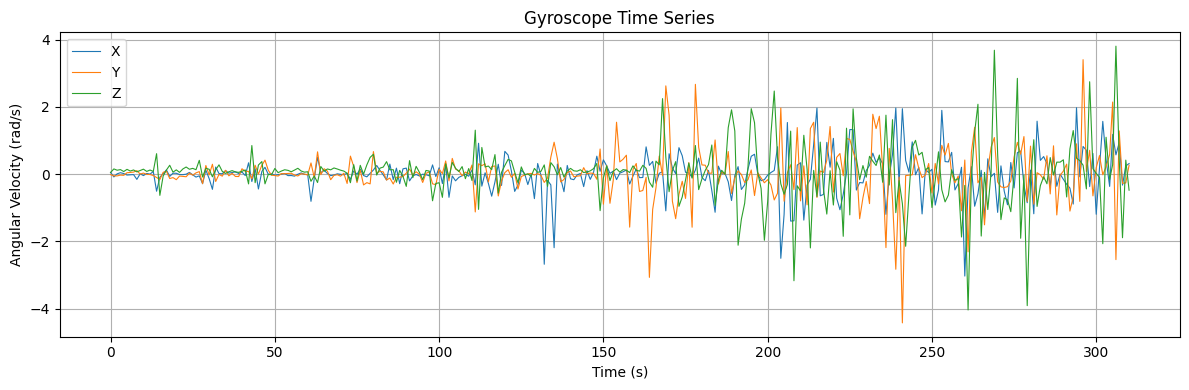

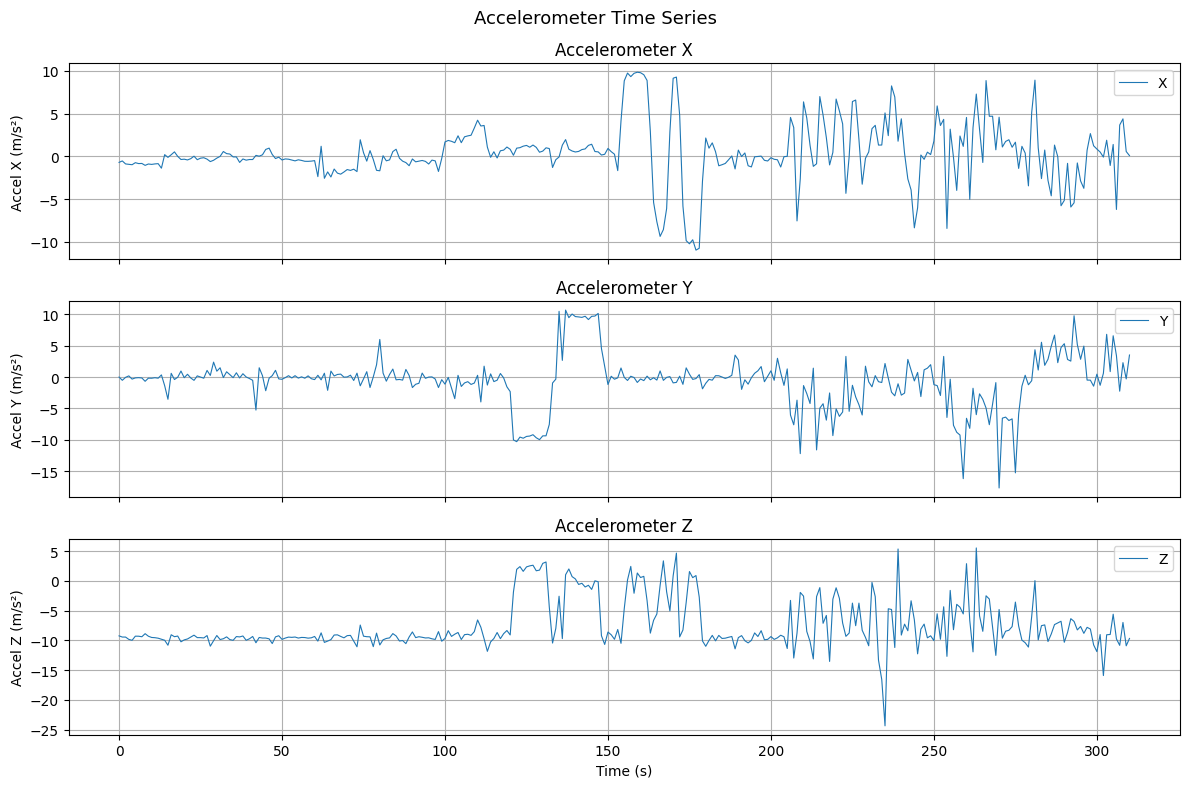

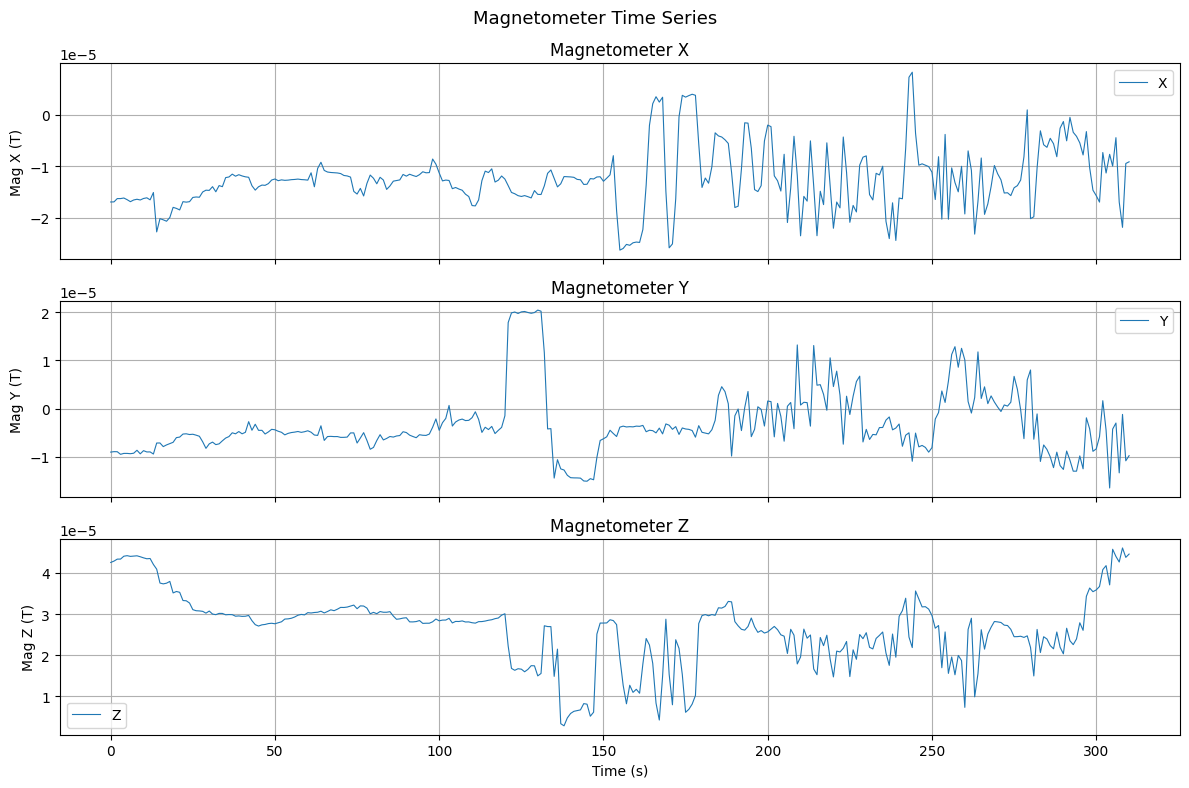

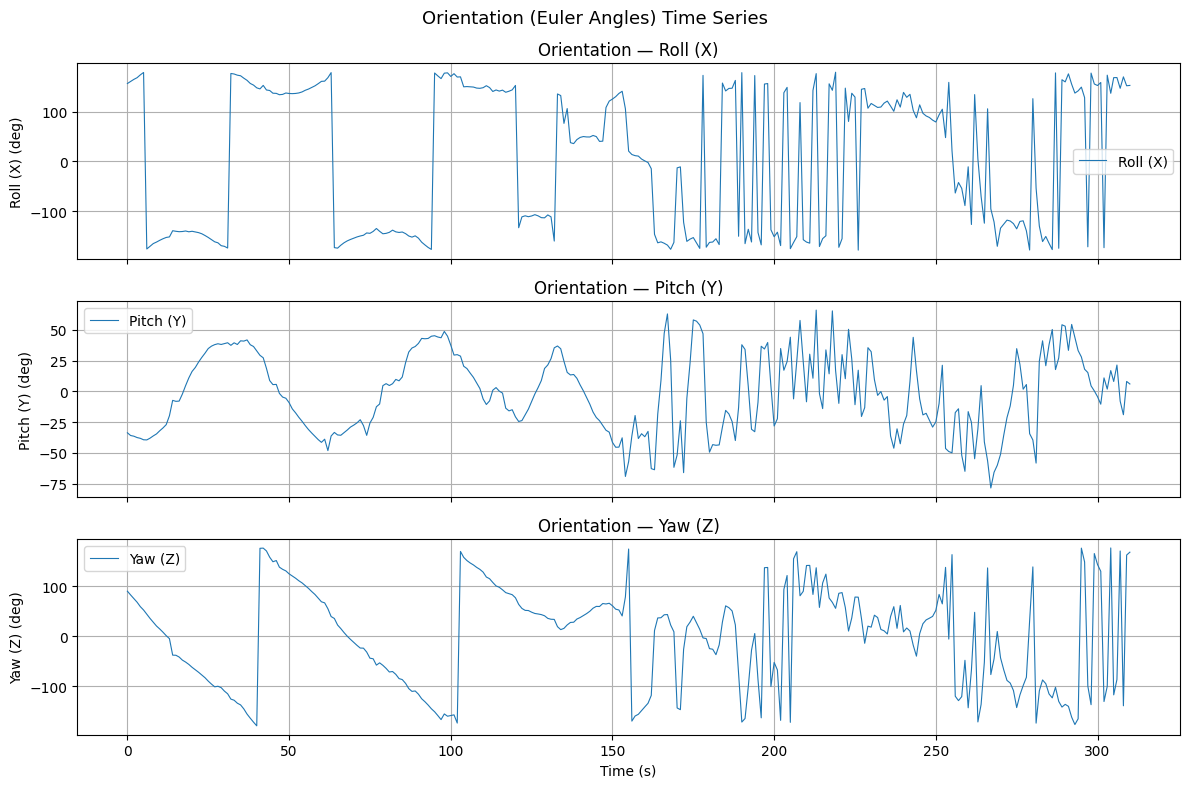

Axis           Mean (deg)   Median (deg)
----------------------------------------
Roll (X)           5.4687        44.1420
Pitch (Y)         -1.5609        -2.1180
Yaw (Z)           -1.2838        15.9730


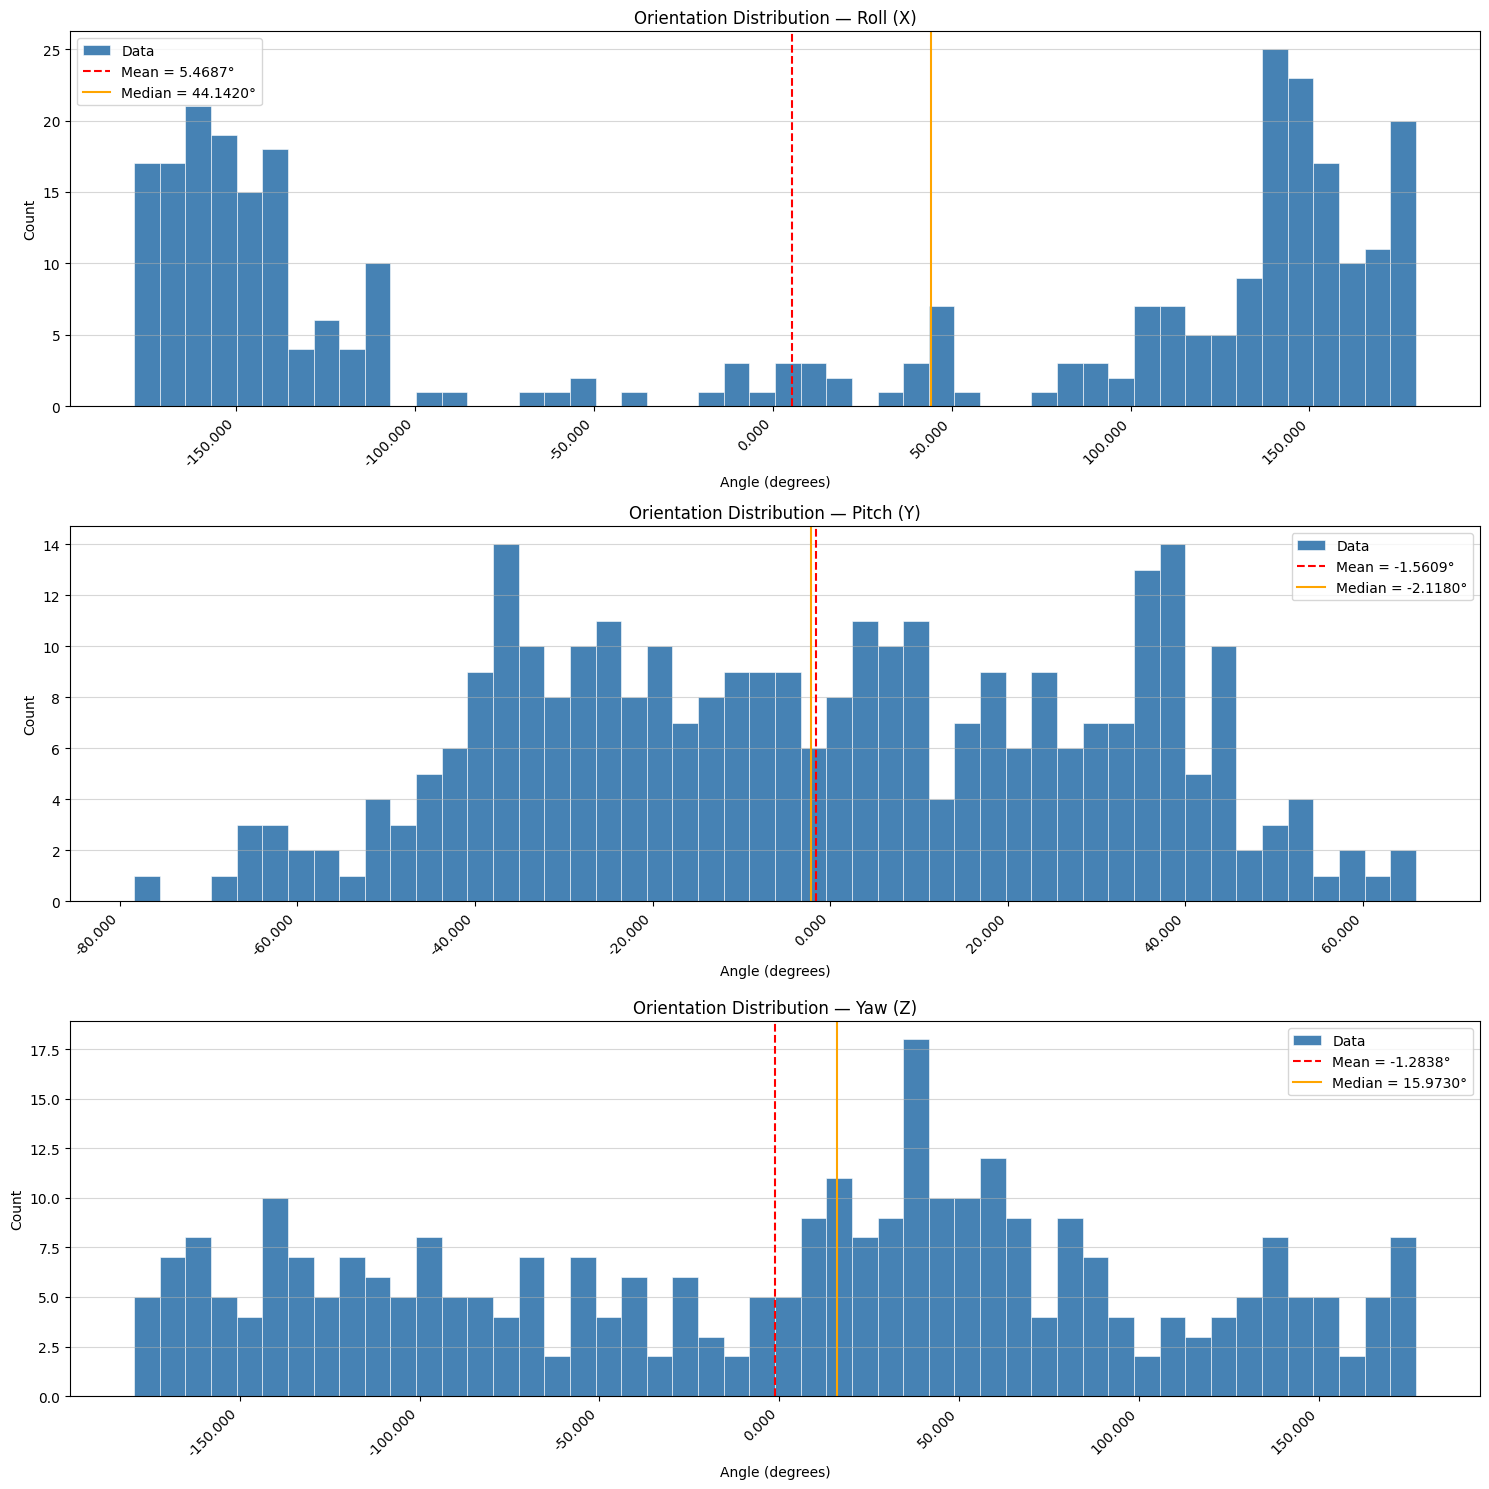

In [64]:
plot_gyro(df)
plot_accel(df)
plot_mag(df)
plot_orientation(df)
print_orientation_stats(df)
plot_orientation_histograms(df)


## Step 1: Find interesting motion windows
Run the full plots above, then note the `time_s` values where interesting motion happens.
Use `plot_clip` below to zoom in on any 5-second (or longer) window.

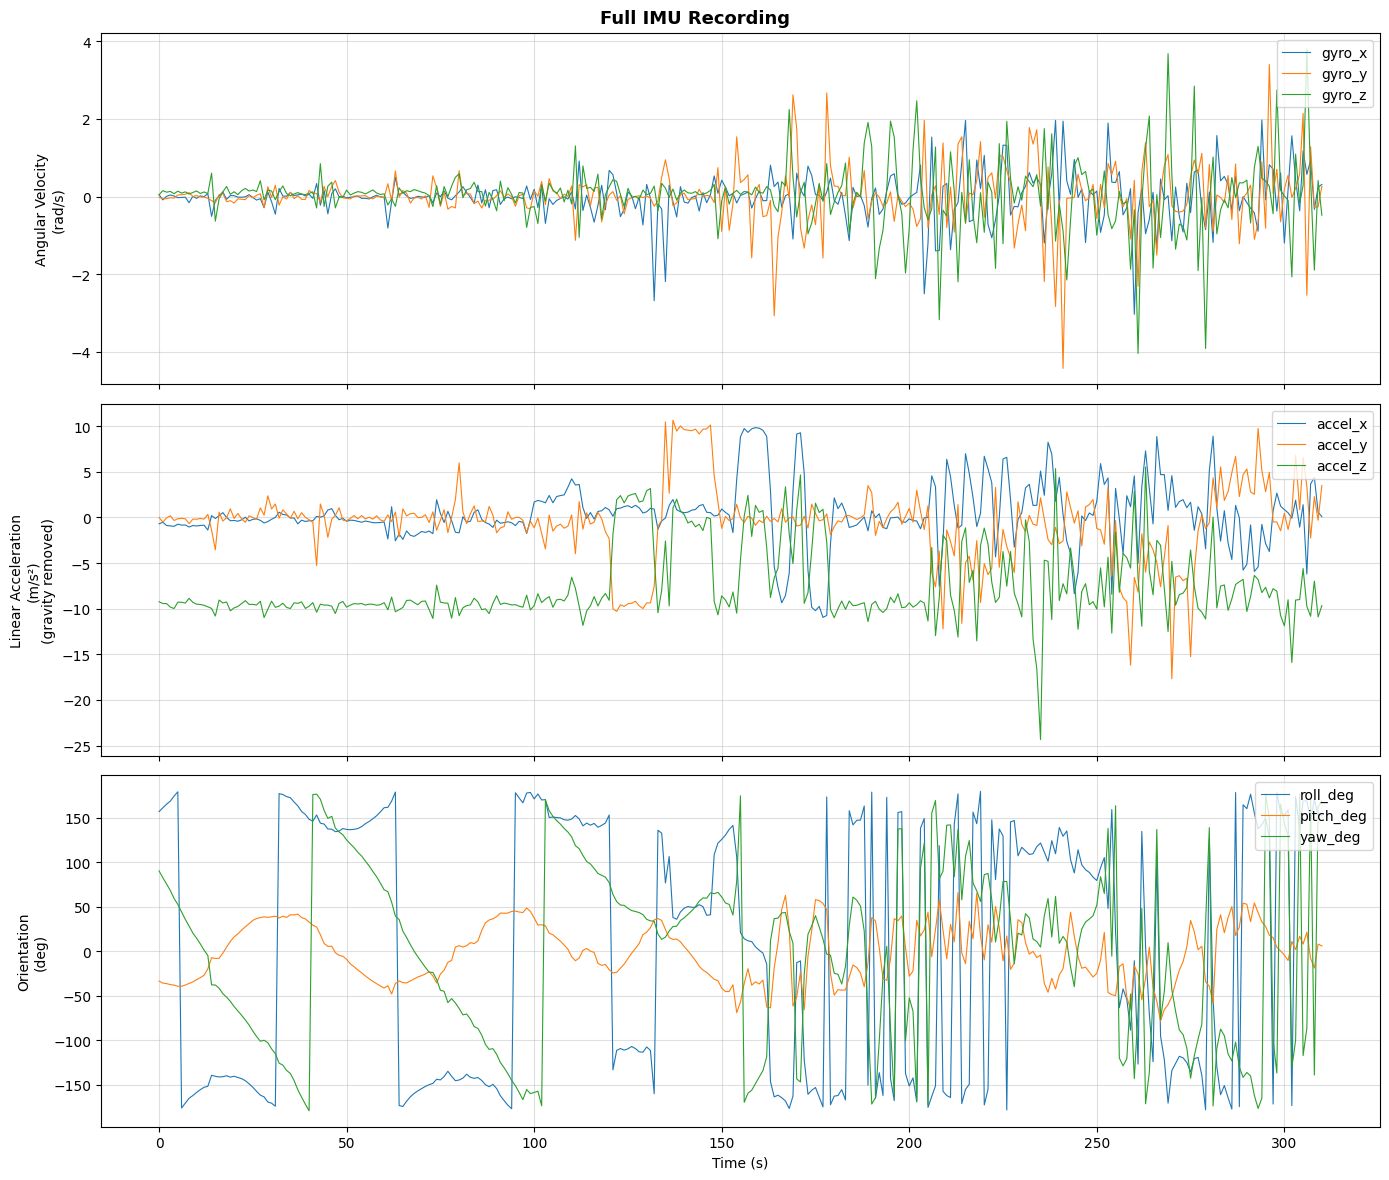

In [65]:
def plot_full_grouped(df, plots=("gyro", "accel", "orientation"), title="Full IMU Recording"):

    plot_config = {
        "gyro": {
            "columns": ["gyro_x", "gyro_y", "gyro_z"],
            "ylabel": "Angular Velocity\n(rad/s)",
        },
        "accel": {
            "columns": ["accel_x", "accel_y", "accel_z"],
            "ylabel": "Linear Acceleration\n(m/s²)\n(gravity removed)",
        },
        "orientation": {
            "columns": ["roll_deg", "pitch_deg", "yaw_deg"],
            "ylabel": "Orientation\n(deg)",
        },
    }

    # Filter to only valid, requested plots (preserving order)
    selected = [p for p in plots if p in plot_config]

    if not selected:
        raise ValueError(f"No valid plots selected. Choose from: {list(plot_config.keys())}")

    fig, axes = plt.subplots(len(selected), 1, figsize=(14, 4 * len(selected)), sharex=True)

    # Ensure axes is always iterable (edge case: only 1 subplot)
    if len(selected) == 1:
        axes = [axes]

    for ax, plot_name in zip(axes, selected):
        config = plot_config[plot_name]
        for col in config["columns"]:
            ax.plot(df["time_s"], df[col], linewidth=0.8, label=col)
        ax.set_ylabel(config["ylabel"])
        ax.legend(loc="upper right")
        ax.grid(True, alpha=0.4)

    axes[-1].set_xlabel("Time (s)")
    fig.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


# Usage examples
plot_full_grouped(df)                                                              


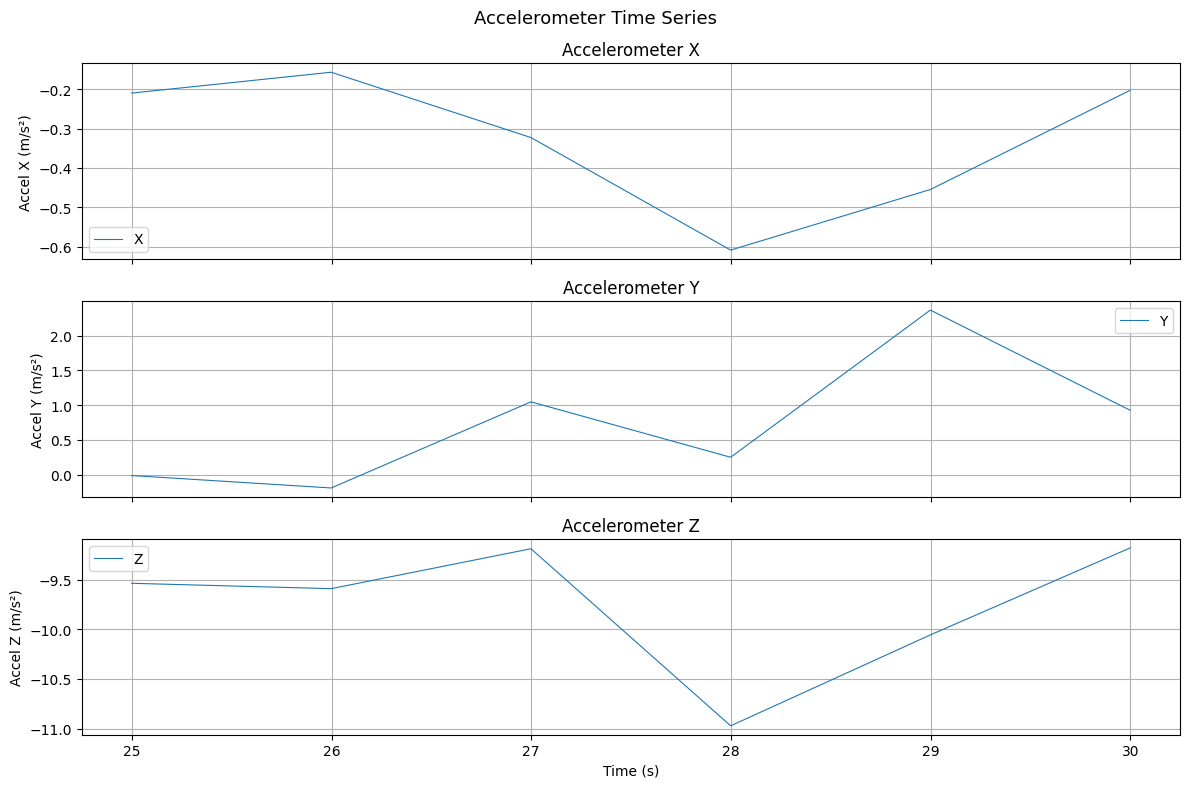

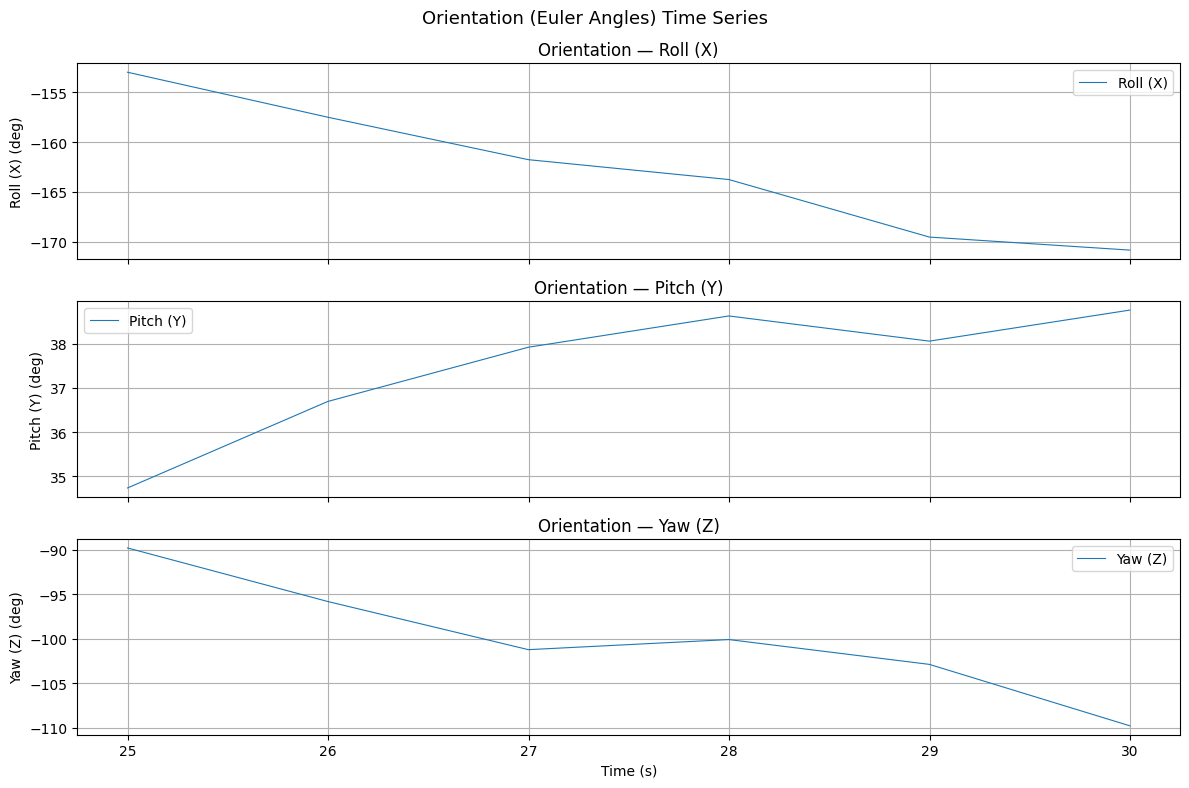

In [88]:
# define the time range for the clip (in seconds)
t1_start, t1_end = 24, 30  # find your timestamp
t2_start, t2_end = 119, 124  # find your timestamp

t1_df = df[(df["time_s"] >= t1_start) & (df["time_s"] <= t1_end)]
plot_accel(t1_df)
plot_orientation(t1_df)

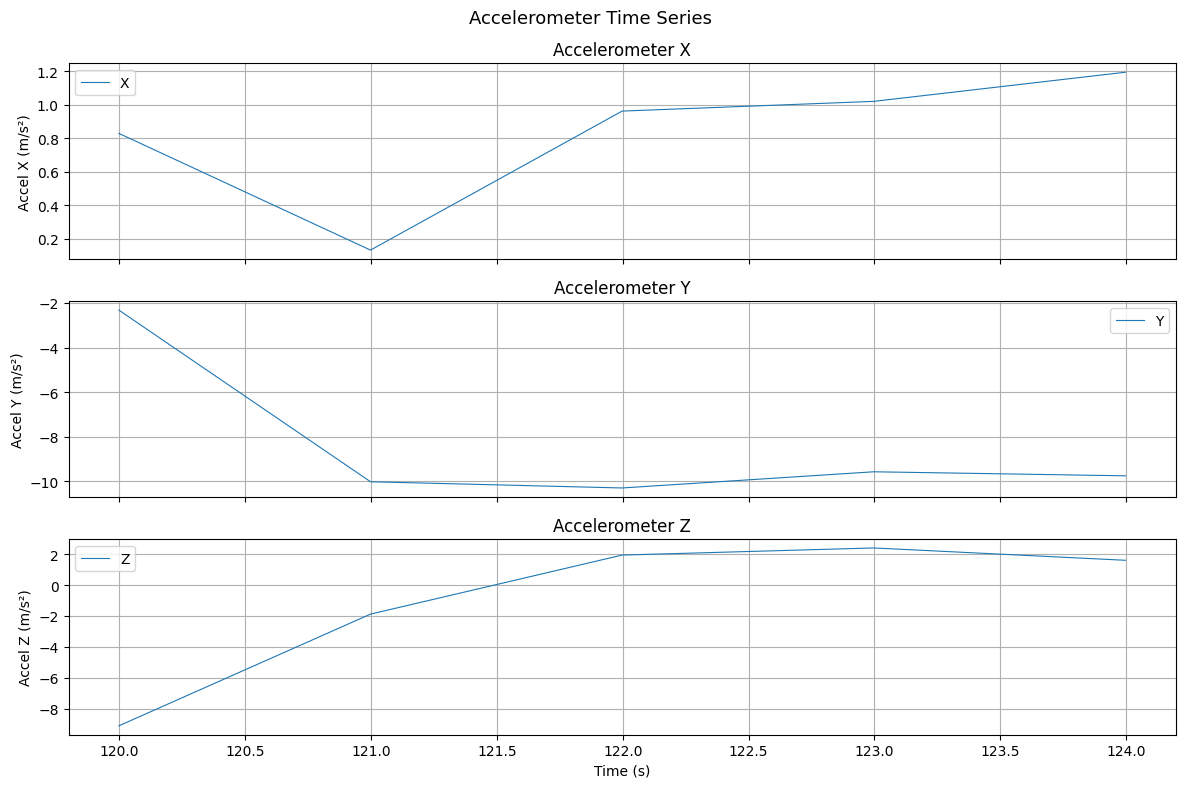

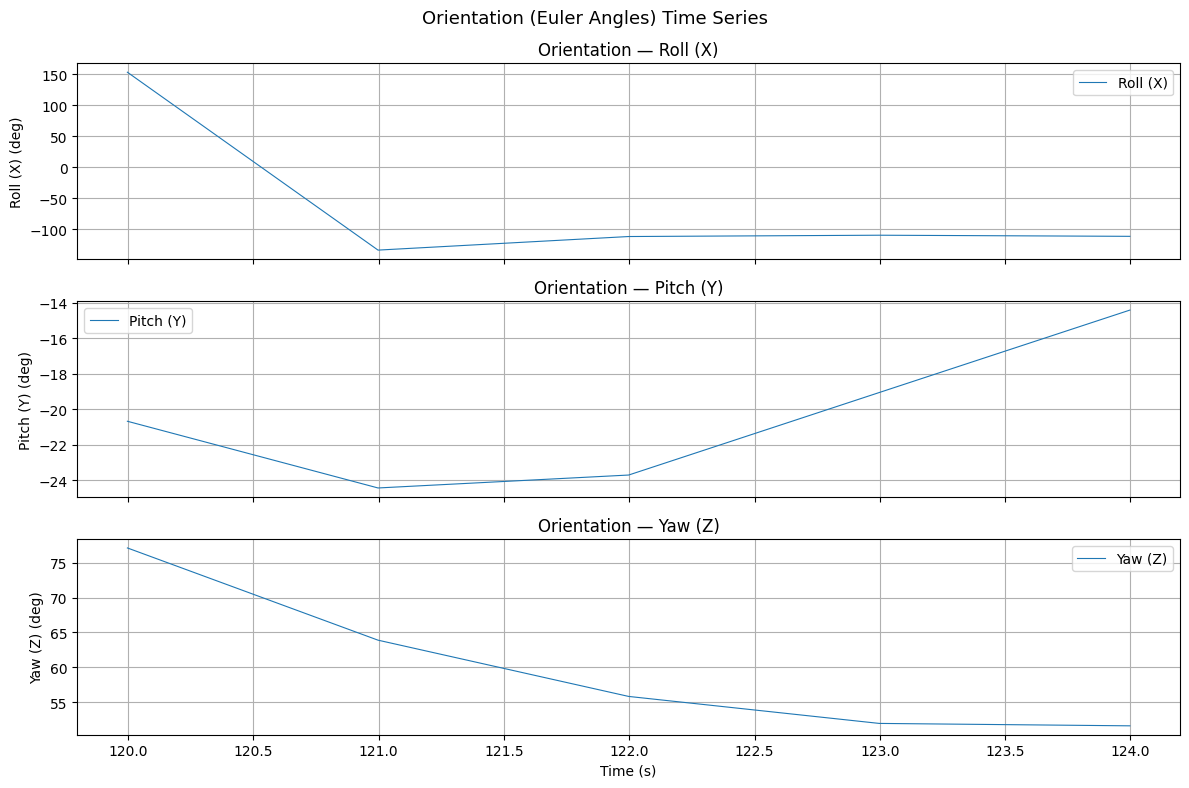

In [91]:
t2_df = df[(df["time_s"] >= t2_start) & (df["time_s"] <= t2_end)]
plot_accel(t2_df)
plot_orientation(t2_df)

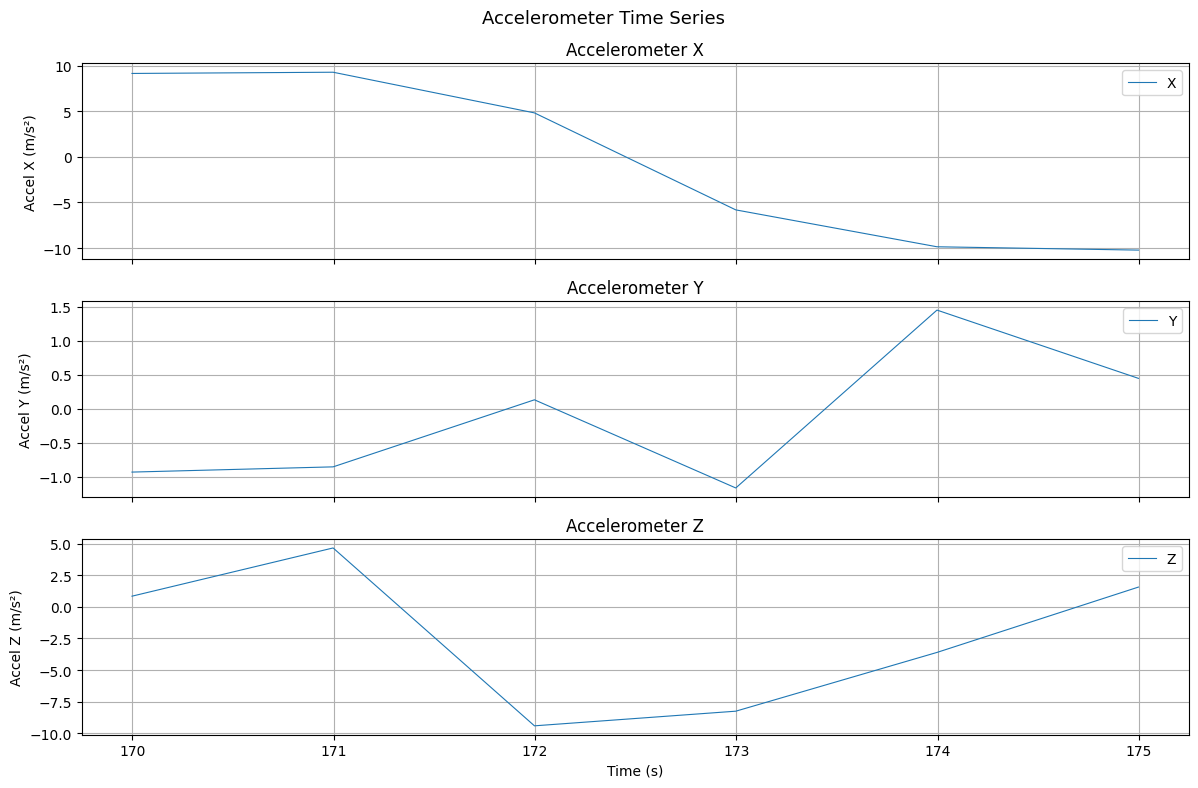

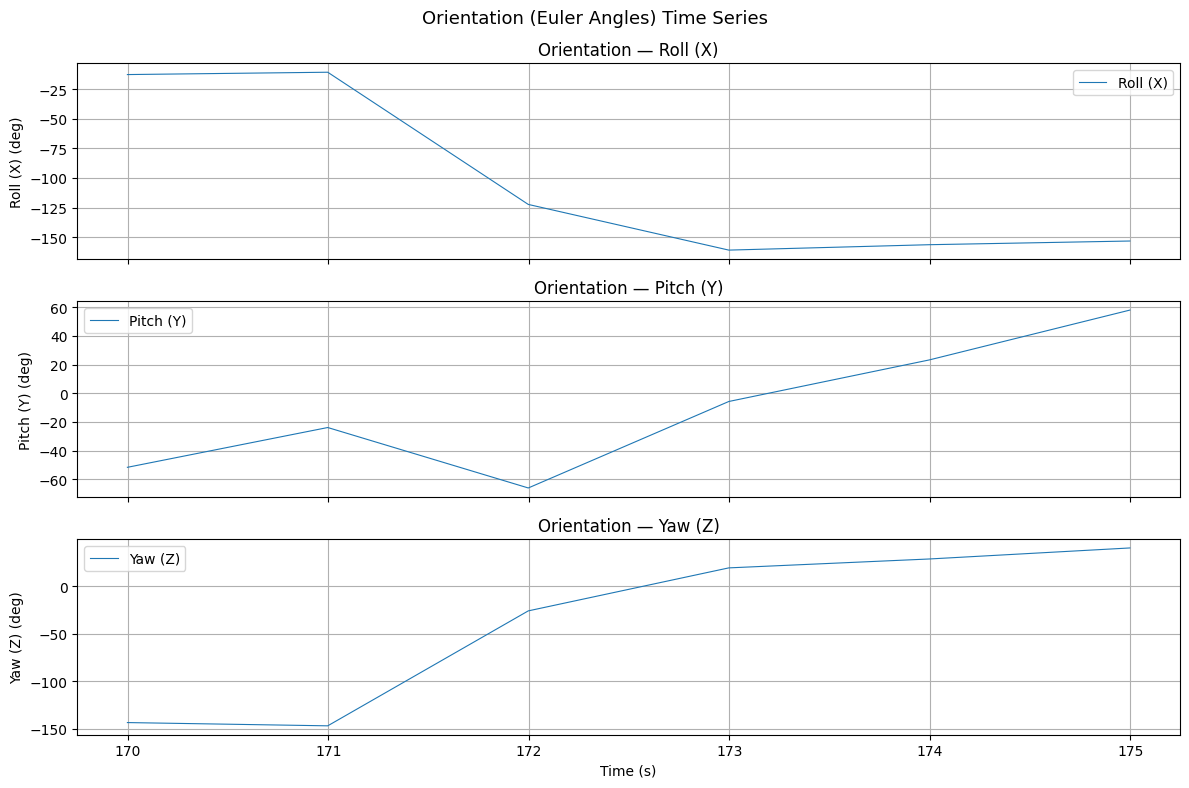

In [92]:
t3_start, t3_end = 169, 175   
t3_df = df[(df["time_s"] >= t3_start) & (df["time_s"] <= t3_end)]
plot_accel(t3_df)
plot_orientation(t3_df)